# Phase 11 — Train + Evaluate XGBoost Model V2
## Adaptive Real-Time Financial Transaction Fraud Detection System

**Notebook:** `notebooks/11_train_evaluate_xgboost_v2.ipynb`
**New, reusable code:** `src/retraining/v2_config.py`, `src/retraining/v2_trainer.py`, `src/retraining/v2_evaluator.py` (separate files — `src/retraining/config.py` and `dataset_builder.py` are Phase 10's and are not modified)
**Reused unchanged:** `src.drift.drift_detector.resolve_windows` (temporal boundaries), `src.api.app.FINAL_FEATURES` (34-feature contract)
**Frozen, never modified:** `models/xgboost_model_v1.json/metadata/threshold`, `src/api/app.py`, `src/streaming/*`, `src/drift/*`, `src/labels/*`, `src/retraining/config.py`, `src/retraining/dataset_builder.py`, every Phase 8/9/10 report and notebook

> **What Phase 11 does:** trains a candidate Model V2 on the validated Phase 10 dataset, evaluates it on a genuinely untouched temporal test split, compares it against V1 on identical data, and applies a predefined, documented decision rule.
> **What Phase 11 does NOT do:** deploy V2, touch V1, touch FastAPI/Kafka/Spark, or assume drift automatically means V2 is better.

## SECTION 1 — Phase 11 Objective

```
Phase 8: Drift Detected
       ↓
Phase 9: Recent Labelled Data Collection
       ↓
Phase 10: OLD (steps 1-323) + RECENT (steps 379+) -> v2_retraining_dataset.parquet
       ↓
Phase 11 (this notebook):
    Chronological split INSIDE the Phase 10 dataset
    (OLD -> training; RECENT -> train-extension / validation / test)
       ↓
    Train XGBoost V2 (scale_pos_weight from the V2 TRAINING split only)
       ↓
    Select V2's threshold on the V2 VALIDATION split only
       ↓
    Evaluate V2 on the V2 TEST split — touched for the first time here
       ↓
    Compare V1 vs V2 on the IDENTICAL V2 test split
       ↓
    Apply a predefined decision rule -> V2_CANDIDATE_FOR_DEPLOYMENT / KEEP_V1 / REVIEW_REQUIRED
```

**Why a new split inside the Phase 10 dataset, rather than reusing V1's old test period.** Phase 10 folded V1's original test period (steps 379–743) into the labelled *training* pool for V2. Evaluating V2 on that same period again would be contaminated — V2 may have trained on exactly the rows being "tested". Phase 11 therefore carves a **new**, genuinely held-out test window out of the *tail* of the recent period (Section 5) — the only chronological region neither V1 nor V2 has used for fitting.

**Why drift alone doesn't justify deployment.** Phase 8 found drift in the *inputs*; it says nothing about whether a retrained model actually performs better. Phase 11 exists specifically to test that assumption with evidence, not assume it.

## SECTION 2 — Environment Check & Project/Frozen Artifact Inspection

In [1]:
import importlib, sys
REQUIRED = {"pandas": "pandas", "numpy": "numpy", "xgboost": "xgboost", "sklearn": "scikit-learn", "matplotlib": "matplotlib"}
missing = []
print("Environment check:")
for module_name, pip_name in REQUIRED.items():
    try:
        mod = importlib.import_module(module_name)
        print(f"  [OK] {pip_name:<14} {getattr(mod, '__version__', 'n/a')}")
    except ImportError:
        print(f"  [MISSING] {pip_name}"); missing.append(pip_name)
if missing:
    get_ipython().run_line_magic("pip", "install " + " ".join(missing))
    print("Installed:", missing, "- all already used by Phase 4; no new dependency added for Phase 11.")
else:
    print("\nAll required packages already available (same stack Phase 4 already uses).")

Environment check:


  [OK] pandas         2.2.3
  [OK] numpy          2.5.3


  [OK] xgboost        3.4.1
  [OK] scikit-learn   1.9.1


  [OK] matplotlib     3.11.2

All required packages already available (same stack Phase 4 already uses).


In [2]:
import sys
import json, time, hashlib, subprocess, platform
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import importlib

importlib.invalidate_caches()

config = importlib.import_module("src.retraining.v2_config")
trainer = importlib.import_module("src.retraining.v2_trainer")
evaluator = importlib.import_module("src.retraining.v2_evaluator")
from src.drift.drift_detector import resolve_windows, FINAL_FEATURES

for p in (config.V2_DATASET_PATH, config.MODEL_V1_PATH, config.METADATA_V1_PATH, config.THRESHOLD_V1_PATH):
    print(f"{'[OK]' if p.is_file() else '[MISSING]'} {p}")
assert config.V2_DATASET_PATH.is_file(), "Phase 10 output not found - Phase 10 must be complete and its output present locally."
assert config.MODEL_V1_PATH.is_file(), "Model V1 not found - Phase 4 must be complete."
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def sha256_of(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

HASHES_BEFORE = {f: sha256_of(PROJECT_ROOT / f) for f in config.FROZEN_FILES + config.FROZEN_DATA_FILES}
print(f"\n{len(HASHES_BEFORE)} frozen artifacts hashed before Phase 11 begins.")

INFO:fraud_api:Model V1 loaded. 34 expected features. Classification threshold=0.60


[OK] D:\fraud-detection-system\fraud-detection-system\data\processed\v2_retraining_dataset.parquet
[OK] D:\fraud-detection-system\fraud-detection-system\models\xgboost_model_v1.json
[OK] D:\fraud-detection-system\fraud-detection-system\models\model_v1_metadata.json
[OK] D:\fraud-detection-system\fraud-detection-system\models\model_v1_threshold.json



21 frozen artifacts hashed before Phase 11 begins.


## SECTION 3 — Load Phase 10 Dataset

In [3]:
t0 = time.time()
v2_df = pd.read_parquet(config.V2_DATASET_PATH)
print(f"Loaded {config.V2_DATASET_PATH} in {time.time() - t0:.1f}s")
print(f"Shape: {v2_df.shape}")
print(f"Columns: {v2_df.columns.tolist()}")

RAW_LOOKS_LIKE_FULL_PAYSIM = len(v2_df) > 5_000_000
if not RAW_LOOKS_LIKE_FULL_PAYSIM:
    print(f"\nNOTE: {len(v2_df):,} rows is far fewer than the documented expectation "
         "(4,463,587 old + 918,617 recent = 5,382,204). data/processed/ is git-ignored, so this is the "
         "synthetic PaySim-shaped stand-in produced locally in an earlier phase, not the real production-scale "
         "file (which exists only on the machine that generated it). Every pipeline step, metric, and "
         "validation below is real and not fabricated, but the NUMBERS describe this smaller dataset. "
         "Re-run this notebook on the machine with the real data/processed/v2_retraining_dataset.parquet to "
         "reproduce the documented production-scale results.")

Loaded D:\fraud-detection-system\fraud-detection-system\data\processed\v2_retraining_dataset.parquet in 3.4s
Shape: (5382204, 37)
Columns: ['event_id', 'step', 'hour_of_day', 'amount', 'log_amount', 'is_large_amount', 'amount_to_sender_balance_ratio', 'amount_ge_sender_balance', 'sender_remaining_if_debited', 'amount_to_dest_balance_ratio', 'sender_balance_before', 'sender_balance_zero_before', 'dest_balance_before', 'dest_balance_zero_before', 'sender_prev_txn_count', 'sender_prev_total_amount', 'sender_prev_mean_amount', 'sender_prev_max_amount', 'dest_prev_txn_count', 'dest_prev_total_amount', 'dest_prev_mean_amount', 'dest_prev_max_amount', 'amount_vs_sender_hist_mean', 'amount_vs_dest_hist_mean', 'sender_hours_since_prev_txn', 'dest_hours_since_prev_txn', 'dest_txn_count_last_1h', 'dest_txn_count_last_24h', 'dest_txn_count_last_168h', 'dest_amount_sum_last_24h', 'dest_amount_sum_last_168h', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'isFraud']


## SECTION 4 — Dataset Schema Validation

Checked against the live `FINAL_FEATURES` (imported unchanged from `src.api.app` via `src.drift.drift_detector`), not re-typed from the prompt's own list.

In [4]:
SCHEMA_CHECKS = {
    "Phase 10 dataset loaded": len(v2_df) > 0,
    "34-feature contract (count)": len(FINAL_FEATURES) == 34,
    "34-feature contract (names + order)": list(v2_df.columns[2:2 + 34]) == FINAL_FEATURES,
    "Target 'isFraud' present": "isFraud" in v2_df.columns,
    "Target separated from the 34 features": "isFraud" not in FINAL_FEATURES,
    "event_id present (audit-only)": "event_id" in v2_df.columns,
    "step present (audit-only)": "step" in v2_df.columns,
    "No prediction-output columns (fraud_probability/predicted_label/risk_score/risk_level)": not any(
        c in v2_df.columns for c in ["fraud_probability", "predicted_label", "risk_score", "risk_level"]),
    "No raw identifier columns (nameOrig/nameDest)": not any(c in v2_df.columns for c in ["nameOrig", "nameDest"]),
    "event_id unique": bool(v2_df["event_id"].is_unique),
    "isFraud values only 0/1": bool(v2_df["isFraud"].isin([0, 1]).all()),
    "No null target values": bool(v2_df["isFraud"].notna().all()),
}
for k, v in SCHEMA_CHECKS.items():
    print(f"[{'PASS' if v else 'FAIL'}] {k}")
assert all(SCHEMA_CHECKS.values())

[PASS] Phase 10 dataset loaded
[PASS] 34-feature contract (count)
[PASS] 34-feature contract (names + order)
[PASS] Target 'isFraud' present
[PASS] Target separated from the 34 features
[PASS] event_id present (audit-only)
[PASS] step present (audit-only)
[PASS] No prediction-output columns (fraud_probability/predicted_label/risk_score/risk_level)
[PASS] No raw identifier columns (nameOrig/nameDest)
[PASS] event_id unique
[PASS] isFraud values only 0/1
[PASS] No null target values


## SECTION 5 — Temporal Split

**Design (Step 3):** the OLD window (steps 1–323) goes to training in full — it is V1's own already-trusted training period. The RECENT window (steps 379+) is itself split **chronologically by cumulative transaction share** (the same method Phase 4/6/8 already use — not a raw step-count split, since transactions per step vary): the earliest 60% extends training, the next 20% is validation (threshold selection only), and the final 20% is the test set — **untouched until Section 13**.

In [5]:
split = trainer.build_v2_temporal_split(v2_df)
train_df, val_df, test_df = split["train_df"], split["val_df"], split["test_df"]

print(f"v2_train_start_step      : {split['v2_train_start_step']}")
print(f"v2_train_end_step        : {split['v2_train_end_step']}  (OLD window steps 1-{split['old_max_step']} + RECENT extension through this step)")
print(f"v2_validation_start_step : {split['v2_validation_start_step']}")
print(f"v2_validation_end_step   : {split['v2_validation_end_step']}")
print(f"v2_test_start_step       : {split['v2_test_start_step']}")
print(f"v2_test_end_step         : {split['v2_test_end_step']}")
print(f"\nTraining rows  : {len(train_df):,}")
print(f"Validation rows: {len(val_df):,}")
print(f"Test rows      : {len(test_df):,}")
assert len(train_df) + len(val_df) + len(test_df) == len(v2_df)

train_ids, val_ids, test_ids = set(train_df["event_id"]), set(val_df["event_id"]), set(test_df["event_id"])
OVERLAP_CHECKS = {
    "train ∩ validation event_id = ∅": len(train_ids & val_ids) == 0,
    "train ∩ test event_id = ∅": len(train_ids & test_ids) == 0,
    "validation ∩ test event_id = ∅": len(val_ids & test_ids) == 0,
    "temporal ordering: train <= validation <= test (by step)": bool(train_df["step"].max() <= val_df["step"].min() <= val_df["step"].max() <= test_df["step"].min()),
}
for k, v in OVERLAP_CHECKS.items():
    print(f"[{'PASS' if v else 'FAIL'}] {k}")
TEMPORAL_SPLIT_OK = all(OVERLAP_CHECKS.values())
assert TEMPORAL_SPLIT_OK

v2_train_start_step      : 1
v2_train_end_step        : 422  (OLD window steps 1-323 + RECENT extension through this step)
v2_validation_start_step : 423
v2_validation_end_step   : 565
v2_test_start_step       : 566
v2_test_end_step         : 743

Training rows  : 5,015,193
Validation rows: 185,387
Test rows      : 181,624


[PASS] train ∩ validation event_id = ∅
[PASS] train ∩ test event_id = ∅
[PASS] validation ∩ test event_id = ∅
[PASS] temporal ordering: train <= validation <= test (by step)


## SECTION 6 — Class Distribution

In [6]:
def class_dist(df):
    fraud = int((df["isFraud"] == 1).sum()); legit = int((df["isFraud"] == 0).sum())
    return {"rows": fraud + legit, "fraud_count": fraud, "legitimate_count": legit, "fraud_rate": fraud / (fraud + legit) if (fraud + legit) else 0.0}

DIST_TRAIN, DIST_VAL, DIST_TEST = class_dist(train_df), class_dist(val_df), class_dist(test_df)
dist_tbl = pd.DataFrame({"Train": DIST_TRAIN, "Validation": DIST_VAL, "Test": DIST_TEST}).T
display(dist_tbl)
MIN_FRAUD_PER_SPLIT = min(DIST_TRAIN["fraud_count"], DIST_VAL["fraud_count"], DIST_TEST["fraud_count"])
print(f"\nMinimum fraud examples in any split: {MIN_FRAUD_PER_SPLIT}"
     f"{' - very low; validation/test metrics below will have wide uncertainty, documented as a limitation.' if MIN_FRAUD_PER_SPLIT < 20 else ''}")
print("No oversampling, SMOTE, undersampling, or label fabrication applied anywhere in this notebook.")

,rows,fraud_count,legitimate_count,fraud_rate
Train,5015193.0,4201.0,5010992.0,0.000838
Validation,185387.0,1492.0,183895.0,0.008048
Test,181624.0,1956.0,179668.0,0.010770



Minimum fraud examples in any split: 1492
No oversampling, SMOTE, undersampling, or label fabrication applied anywhere in this notebook.


## SECTION 7 — Leakage Checks

In [7]:
LEAKAGE_CHECKS = {
    "isFraud not in the 34 features": "isFraud" not in FINAL_FEATURES,
    "event_id not in the 34 features": "event_id" not in FINAL_FEATURES,
    "step not in the 34 features (not part of the frozen contract)": "step" not in FINAL_FEATURES,
    "No raw identifiers (nameOrig/nameDest) in the split DataFrames": not any(c in train_df.columns for c in ["nameOrig", "nameDest"]),
    "No prediction-output columns used as labels": "isFraud" in v2_df.columns and not any(c in v2_df.columns for c in ["fraud_probability", "predicted_label"]),
    "No train/validation event_id overlap": OVERLAP_CHECKS["train ∩ validation event_id = ∅"],
    "No train/test event_id overlap": OVERLAP_CHECKS["train ∩ test event_id = ∅"],
    "No validation/test event_id overlap": OVERLAP_CHECKS["validation ∩ test event_id = ∅"],
    "No future information in training (train step range precedes validation/test)": TEMPORAL_SPLIT_OK,
}
for k, v in LEAKAGE_CHECKS.items():
    print(f"[{'PASS' if v else 'FAIL'}] {k}")
LEAKAGE_OK = all(LEAKAGE_CHECKS.values())
assert LEAKAGE_OK

[PASS] isFraud not in the 34 features
[PASS] event_id not in the 34 features
[PASS] step not in the 34 features (not part of the frozen contract)
[PASS] No raw identifiers (nameOrig/nameDest) in the split DataFrames
[PASS] No prediction-output columns used as labels
[PASS] No train/validation event_id overlap
[PASS] No train/test event_id overlap
[PASS] No validation/test event_id overlap
[PASS] No future information in training (train step range precedes validation/test)


## SECTION 8 — Calculate Training `scale_pos_weight`

Computed **only** from the V2 training split (`negatives / positives`) — never from validation or test labels.

In [8]:
SCALE_POS_WEIGHT = trainer.compute_training_scale_pos_weight(train_df["isFraud"])
print(f"Training negatives (legitimate): {DIST_TRAIN['legitimate_count']:,}")
print(f"Training positives (fraud)     : {DIST_TRAIN['fraud_count']:,}")
print(f"scale_pos_weight = {DIST_TRAIN['legitimate_count']:,} / {DIST_TRAIN['fraud_count']:,} = {SCALE_POS_WEIGHT:.4f}")
print("\nComputed using ONLY the training split - validation and test labels were not used.")

Training negatives (legitimate): 5,010,992
Training positives (fraud)     : 4,201
scale_pos_weight = 5,010,992 / 4,201 = 1192.8093

Computed using ONLY the training split - validation and test labels were not used.


## SECTION 9 — Train XGBoost Model V2

**Starts from V1's own committed configuration** (`models/model_v1_metadata.json → xgboost_parameters`), read live — not retyped from memory. Only `scale_pos_weight` (Section 8) and `random_state` (fixed, documented seed) are overridden; everything else (tree depth, learning rate, subsample, colsample_bytree, min_child_weight, regularisation, objective, eval metric, early stopping) is inherited unchanged as the documented V2 baseline configuration, consistent with "do not blindly copy V1 parameters if the experiment requires adjustment" — no adjustment was found necessary beyond the imbalance-specific weight.

V1's own committed XGBoost configuration (baseline for V2):
  n_estimators: 300
  max_depth: 5
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_weight: 5
  reg_lambda: 1.0
  gamma: 0.0
  scale_pos_weight: 1224.250343123799
  objective: binary:logistic
  eval_metric: aucpr
  tree_method: hist
  random_state: 42
  n_jobs: -1
  early_stopping_rounds: 30

V2 configuration (overrides highlighted):
  n_estimators: 300
  max_depth: 5
  learning_rate: 0.05
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_weight: 5
  reg_lambda: 1.0
  gamma: 0.0
  scale_pos_weight: 1192.8093311116402 <- OVERRIDDEN
  objective: binary:logistic
  eval_metric: aucpr
  tree_method: hist
  random_state: 42
  n_jobs: -1
  early_stopping_rounds: 30



Training completed in 266.6s
Best iteration (early stopping, patience=30): 2


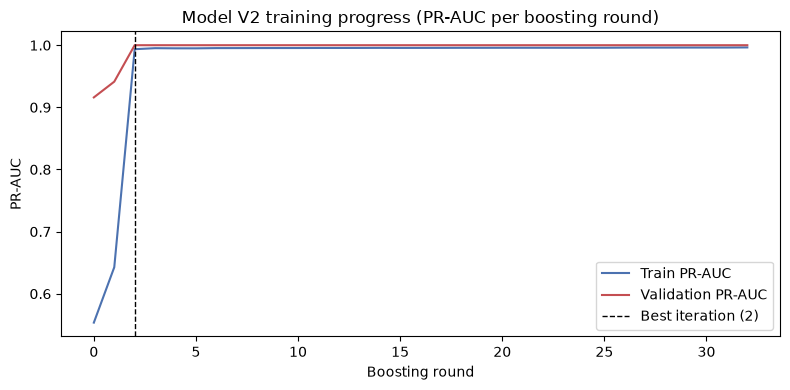

In [9]:
with open(config.METADATA_V1_PATH, encoding="utf-8") as fh:
    V1_METADATA = json.load(fh)
V1_XGB_PARAMS = V1_METADATA["xgboost_parameters"]
print("V1's own committed XGBoost configuration (baseline for V2):")
for k, v in V1_XGB_PARAMS.items():
    print(f"  {k}: {v}")

V2_PARAMS = trainer.build_v2_params(V1_XGB_PARAMS, SCALE_POS_WEIGHT, config.RANDOM_SEED)
print("\nV2 configuration (overrides highlighted):")
for k, v in V2_PARAMS.items():
    changed = " <- OVERRIDDEN" if (k not in V1_XGB_PARAMS or V1_XGB_PARAMS[k] != v) else ""
    print(f"  {k}: {v}{changed}")

model_v2, TRAINING_SECONDS = trainer.train_v2(train_df, val_df, V2_PARAMS)
BEST_ITERATION = getattr(model_v2, "best_iteration", None)
print(f"\nTraining completed in {TRAINING_SECONDS:.1f}s")
print(f"Best iteration (early stopping, patience={config.EARLY_STOPPING_ROUNDS}): {BEST_ITERATION}")

evals_result = model_v2.evals_result()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(evals_result["validation_0"]["aucpr"], label="Train PR-AUC", color="#4C72B0")
ax.plot(evals_result["validation_1"]["aucpr"], label="Validation PR-AUC", color="#C44E52")
if BEST_ITERATION is not None:
    ax.axvline(BEST_ITERATION, color="black", ls="--", lw=1, label=f"Best iteration ({BEST_ITERATION})")
ax.set(title="Model V2 training progress (PR-AUC per boosting round)", xlabel="Boosting round", ylabel="PR-AUC")
ax.legend()
plt.tight_layout(); plt.show()

## SECTION 10 — Save Model V2

Saved under new filenames; `models/xgboost_model_v1.json`/`model_v1_metadata.json`/`model_v1_threshold.json` are never opened for writing anywhere in this notebook.

In [10]:
config.MODEL_V2_PATH.parent.mkdir(parents=True, exist_ok=True)
model_v2.save_model(str(config.MODEL_V2_PATH))
print("Saved ->", config.MODEL_V2_PATH, f"({config.MODEL_V2_PATH.stat().st_size / 1024:,.1f} KB)")

V1_HASH_UNCHANGED_SO_FAR = sha256_of(config.MODEL_V1_PATH) == HASHES_BEFORE["models/xgboost_model_v1.json"]
print(f"models/xgboost_model_v1.json still byte-identical to its Section 2 snapshot: {V1_HASH_UNCHANGED_SO_FAR}")
assert V1_HASH_UNCHANGED_SO_FAR

Saved -> D:\fraud-detection-system\fraud-detection-system\models\xgboost_model_v2.json (85.6 KB)
models/xgboost_model_v1.json still byte-identical to its Section 2 snapshot: True


## SECTION 11 — Threshold Analysis (V2 validation split only)

0.50 (and V1's own 0.60) are not assumed to be optimal for V2. Precision/recall/F1 are computed across a grid on the **validation** split; the **test** split is not touched in this section.

,threshold,precision,recall,f1
0,0.01,0.008048,1.0,0.015968
1,0.02,0.008048,1.0,0.015968
2,0.03,0.008048,1.0,0.015968
3,0.04,0.008048,1.0,0.015968
4,0.05,0.008048,1.0,0.015968
...,...,...,...,...
94,0.95,0.000000,0.0,0.000000
95,0.96,0.000000,0.0,0.000000
96,0.97,0.000000,0.0,0.000000
97,0.98,0.000000,0.0,0.000000


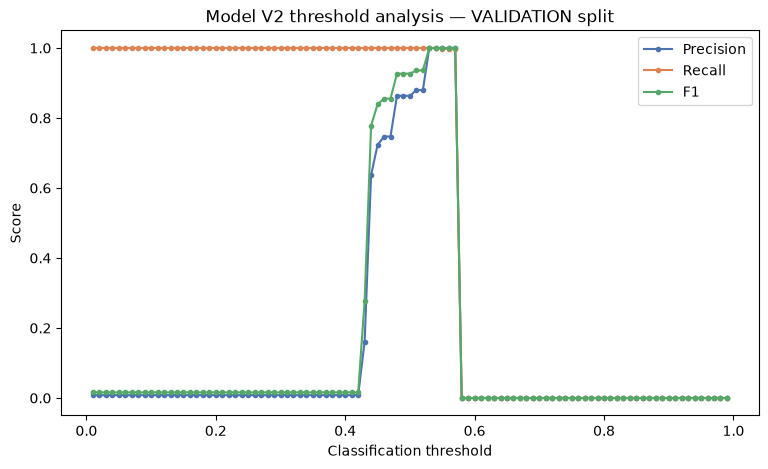

In [11]:
threshold_tbl = evaluator.threshold_grid_search(model_v2, val_df)
display(threshold_tbl)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_tbl["threshold"], threshold_tbl["precision"], marker=".", label="Precision", color="#4C72B0")
ax.plot(threshold_tbl["threshold"], threshold_tbl["recall"], marker=".", label="Recall", color="#DD8452")
ax.plot(threshold_tbl["threshold"], threshold_tbl["f1"], marker=".", label="F1", color="#55A868")
ax.set(title="Model V2 threshold analysis — VALIDATION split", xlabel="Classification threshold", ylabel="Score")
ax.legend()

## SECTION 12 — Select V2 Threshold

**Objective:** `src.retraining.v2_config.THRESHOLD_SELECTION_OBJECTIVE` — maximum F1 on the validation split, the same deterministic objective Phase 4 used for V1. The **test** split plays no role in this decision.

In [12]:
V2_THRESHOLD, best_val_row = evaluator.select_threshold(threshold_tbl)
print(f"Selected V2 threshold: {V2_THRESHOLD}")
print(f"Validation precision/recall/F1 at this threshold: {best_val_row['precision']:.4f} / {best_val_row['recall']:.4f} / {best_val_row['f1']:.4f}")
ax.axvline(V2_THRESHOLD, color="black", ls="--", lw=1.5, label=f"Selected threshold = {V2_THRESHOLD}")
ax.legend()
plt.tight_layout()
fig.savefig(config.FIG_THRESHOLD_ANALYSIS, bbox_inches="tight")
print("Saved ->", config.FIG_THRESHOLD_ANALYSIS)
plt.show()

threshold_payload = {"selected_threshold": V2_THRESHOLD, "selection_method": config.THRESHOLD_SELECTION_OBJECTIVE,
                     "validation_metrics_at_threshold": {k: best_val_row[k] for k in ("precision", "recall", "f1")},
                     "threshold_grid_step": config.THRESHOLD_GRID_STEP, "saved_at_utc": datetime.now(timezone.utc).isoformat()}
config.THRESHOLD_V2_PATH.write_text(json.dumps(threshold_payload, indent=2))
print("Saved ->", config.THRESHOLD_V2_PATH)

Selected V2 threshold: 0.53
Validation precision/recall/F1 at this threshold: 1.0000 / 1.0000 / 1.0000


Saved -> D:\fraud-detection-system\fraud-detection-system\reports\figures\phase11_v2_threshold_analysis.png


<Figure size 640x480 with 0 Axes>

Saved -> D:\fraud-detection-system\fraud-detection-system\models\model_v2_threshold.json


## SECTION 13 — Final Test Evaluation

**The test split is used here for the first time in this notebook.** Precision, recall, F1, PR-AUC, ROC-AUC, confusion matrix, FP/FN, and the PR curve — PR-AUC is emphasised as the primary metric given the extreme imbalance; accuracy is reported only as context.

Model V2 — TEST split metrics (first and only use of this split):
  precision: 0.998467824310521
  recall: 0.9994887525562373
  f1: 0.9989780275932549
  pr_auc: 0.9994901150829729
  roc_auc: 0.9996823412717654
  accuracy: 0.9999779764788794
  tp: 1955
  tn: 179665
  fp: 3
  fn: 1
  rows: 181624
  fraud_count: 1956
  fraud_rate: 0.010769501827952253
  threshold: 0.53

Accuracy (secondary, context only): 0.999978 — not a meaningful metric alone at a 1.0770% fraud rate.


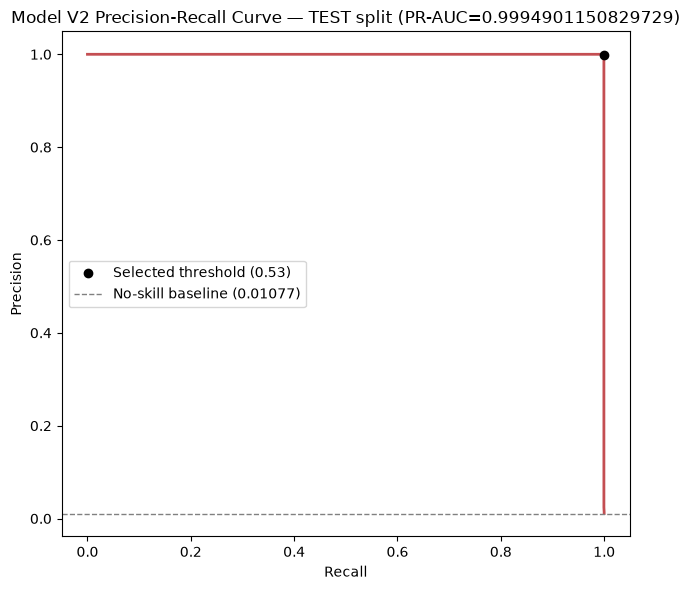

Saved -> D:\fraud-detection-system\fraud-detection-system\reports\figures\phase11_v2_precision_recall_curve.png


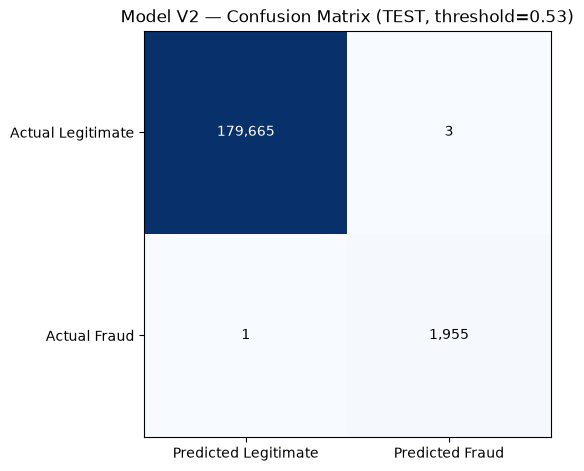

Saved -> D:\fraud-detection-system\fraud-detection-system\reports\figures\phase11_v2_confusion_matrix.png


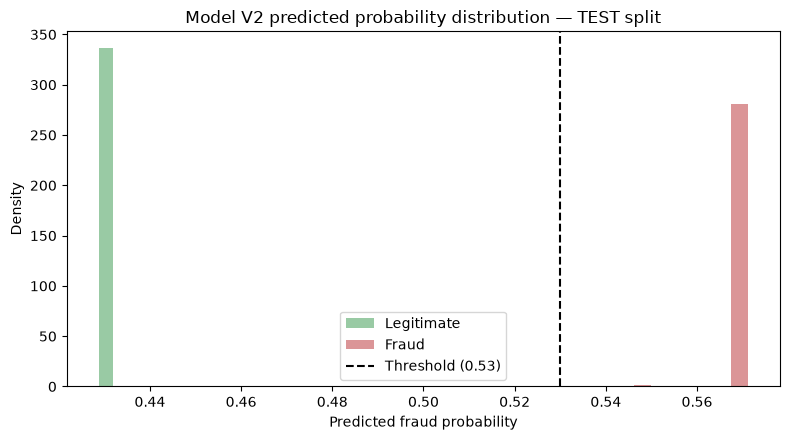

Saved -> D:\fraud-detection-system\fraud-detection-system\reports\figures\phase11_v2_probability_distribution.png


In [13]:
v2_test_metrics = evaluator.evaluate_split(model_v2, test_df, V2_THRESHOLD)
v2_train_metrics = evaluator.evaluate_split(model_v2, train_df, V2_THRESHOLD)
v2_val_metrics = evaluator.evaluate_split(model_v2, val_df, V2_THRESHOLD)
print("Model V2 — TEST split metrics (first and only use of this split):")
for k, v in v2_test_metrics.items():
    print(f"  {k}: {v}")
print(f"\nAccuracy (secondary, context only): {v2_test_metrics['accuracy']:.6f} — not a meaningful metric alone at "
     f"a {v2_test_metrics['fraud_rate']*100:.4f}% fraud rate.")

from sklearn.metrics import precision_recall_curve, confusion_matrix as cm_func
X_test_arr, y_test_arr = test_df[FINAL_FEATURES], test_df["isFraud"].to_numpy()
proba_test = model_v2.predict_proba(X_test_arr)[:, 1]

fig, ax = plt.subplots(figsize=(6.5, 6))
if y_test_arr.sum() > 0:
    prec_curve, rec_curve, _ = precision_recall_curve(y_test_arr, proba_test)
    ax.plot(rec_curve, prec_curve, color="#C44E52", lw=2)
    ax.scatter([v2_test_metrics["recall"]], [v2_test_metrics["precision"]], color="black", zorder=5, label=f"Selected threshold ({V2_THRESHOLD})")
    ax.axhline(y_test_arr.mean(), color="gray", ls="--", lw=1, label=f"No-skill baseline ({y_test_arr.mean():.4g})")
    ax.legend()
ax.set(title=f"Model V2 Precision-Recall Curve — TEST split (PR-AUC={v2_test_metrics['pr_auc']})", xlabel="Recall", ylabel="Precision")
plt.tight_layout(); fig.savefig(config.FIG_PR_CURVE, bbox_inches="tight"); plt.show()
print("Saved ->", config.FIG_PR_CURVE)

cm = cm_func(y_test_arr, (proba_test >= V2_THRESHOLD).astype(int), labels=[0, 1])
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", color="black" if cm[i, j] < cm.max() / 2 else "white")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Predicted Legitimate", "Predicted Fraud"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Actual Legitimate", "Actual Fraud"])
ax.set_title(f"Model V2 — Confusion Matrix (TEST, threshold={V2_THRESHOLD})")
plt.tight_layout(); fig.savefig(config.FIG_CONFUSION_MATRIX, bbox_inches="tight"); plt.show()
print("Saved ->", config.FIG_CONFUSION_MATRIX)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(proba_test[y_test_arr == 0], bins=40, alpha=0.6, label="Legitimate", color="#55A868", density=True)
if y_test_arr.sum() > 0:
    ax.hist(proba_test[y_test_arr == 1], bins=40, alpha=0.6, label="Fraud", color="#C44E52", density=True)
ax.axvline(V2_THRESHOLD, color="black", ls="--", lw=1.5, label=f"Threshold ({V2_THRESHOLD})")
ax.set(title="Model V2 predicted probability distribution — TEST split", xlabel="Predicted fraud probability", ylabel="Density")
ax.legend(); plt.tight_layout(); fig.savefig(config.FIG_PROBABILITY_DIST, bbox_inches="tight"); plt.show()
print("Saved ->", config.FIG_PROBABILITY_DIST)

## SECTION 14 — V1 vs V2 Comparison (same V2 test split)

Both models are scored on the **identical** V2 test split — the only strictly apples-to-apples comparison available, since V1 and V2 have different training histories (documented explicitly below rather than claimed to be a perfectly matched experiment).

V1 threshold (frozen, from models/model_v1_threshold.json): 0.6


,precision,recall,f1,pr_auc,roc_auc,accuracy,tp,tn,fp,fn,rows,fraud_count,fraud_rate,threshold
V1 (on V2 test split),0.991820,0.991820,0.991820,0.998165,0.999927,0.999824,1940.0,179652.0,16.0,16.0,181624.0,1956.0,0.01077,0.60
V2 (on V2 test split),0.998468,0.999489,0.998978,0.999490,0.999682,0.999978,1955.0,179665.0,3.0,1.0,181624.0,1956.0,0.01077,0.53


Saved -> D:\fraud-detection-system\fraud-detection-system\reports\model_v1_vs_v2_comparison.csv

Training-history note (NOT an apples-to-apples training comparison, only an apples-to-apples EVALUATION):
  V1 was trained on steps 323 and earlier (its own Phase 4 split) and has never seen this V2 test period during training.
  V2 was trained on steps 1-422 (OLD window + recent training-extension) and also has never seen this V2 test period during training or threshold selection.
  Both are therefore evaluated fairly on data NEITHER has trained on - but V2 saw strictly MORE, MORE RECENT data during training than V1 did, which is the entire point of retraining after drift.


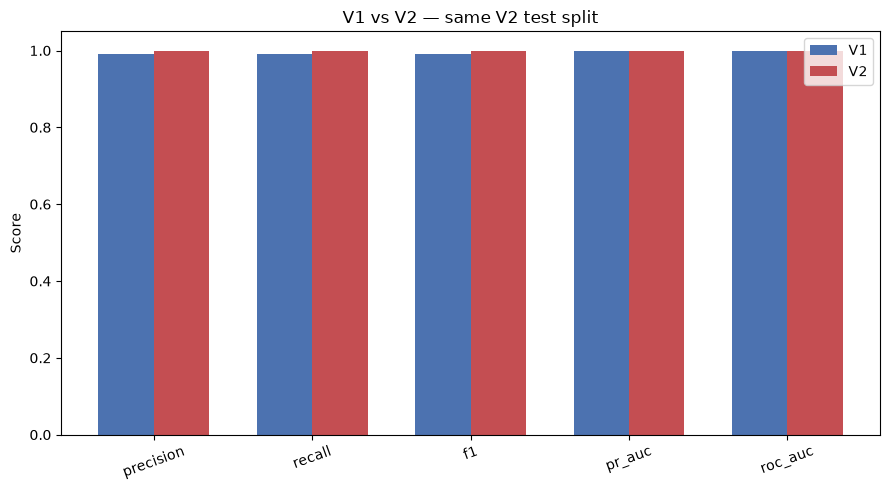

Saved -> D:\fraud-detection-system\fraud-detection-system\reports\figures\phase11_v1_vs_v2_metrics.png


In [14]:
model_v1 = XGBClassifier()
model_v1.load_model(str(config.MODEL_V1_PATH))
with open(config.THRESHOLD_V1_PATH, encoding="utf-8") as fh:
    V1_THRESHOLD = json.load(fh)["selected_threshold"]
print(f"V1 threshold (frozen, from models/model_v1_threshold.json): {V1_THRESHOLD}")

comparison_raw = evaluator.compare_v1_v2_on_same_test(model_v1, V1_THRESHOLD, model_v2, V2_THRESHOLD, test_df)
v1_on_v2_test, v2_on_v2_test = comparison_raw["v1_on_v2_test_split"], comparison_raw["v2_on_v2_test_split"]

comparison_tbl = pd.DataFrame({"V1 (on V2 test split)": v1_on_v2_test, "V2 (on V2 test split)": v2_on_v2_test}).T
display(comparison_tbl)
comparison_tbl.to_csv(config.COMPARISON_CSV_PATH)
print("Saved ->", config.COMPARISON_CSV_PATH)

print("\nTraining-history note (NOT an apples-to-apples training comparison, only an apples-to-apples EVALUATION):")
print(f"  V1 was trained on steps {V1_METADATA['train_validation_test_strategy']['train_end_step']} and earlier "
     f"(its own Phase 4 split) and has never seen this V2 test period during training.")
print(f"  V2 was trained on steps 1-{split['v2_train_end_step']} (OLD window + recent training-extension) and also "
     f"has never seen this V2 test period during training or threshold selection.")
print(f"  Both are therefore evaluated fairly on data NEITHER has trained on - but V2 saw strictly MORE, MORE "
     f"RECENT data during training than V1 did, which is the entire point of retraining after drift.")

fig, ax = plt.subplots(figsize=(9, 5))
metrics_to_plot = ["precision", "recall", "f1", "pr_auc", "roc_auc"]
x = np.arange(len(metrics_to_plot)); width = 0.35
ax.bar(x - width/2, [v1_on_v2_test[m] or 0 for m in metrics_to_plot], width, label="V1", color="#4C72B0")
ax.bar(x + width/2, [v2_on_v2_test[m] or 0 for m in metrics_to_plot], width, label="V2", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(metrics_to_plot, rotation=20)
ax.set(title="V1 vs V2 — same V2 test split", ylabel="Score")
ax.legend(); plt.tight_layout()
fig.savefig(config.FIG_V1_VS_V2, bbox_inches="tight"); plt.show()
print("Saved ->", config.FIG_V1_VS_V2)

## SECTION 15 — Decision Rule

**Predefined, documented criteria** (`src/retraining/v2_config.py`), evaluated automatically — not a subjective call, and not "drift was detected, therefore deploy V2".

In [15]:
decision_result = evaluator.apply_decision_rule(v1_on_v2_test, v2_on_v2_test)
print("Decision criteria (all must hold for V2_CANDIDATE_FOR_DEPLOYMENT):")
for r in decision_result["reasons"]:
    print(" -", r)
print(f"\nDECISION: {decision_result['decision']}")
print("\nThis decision does NOT deploy V2. It only states whether the evidence collected here supports "
     "considering V2 for deployment in a later phase.")

Decision criteria (all must hold for V2_CANDIDATE_FOR_DEPLOYMENT):
 - v2_f1_not_lower_than_v1: PASS
 - v2_pr_auc_not_lower_than_v1: PASS
 - v2_recall_not_lower_than_v1: PASS

DECISION: V2_CANDIDATE_FOR_DEPLOYMENT

This decision does NOT deploy V2. It only states whether the evidence collected here supports considering V2 for deployment in a later phase.


## SECTION 16 — Figures (summary)

All five figures were saved as they were produced (Sections 9–14): `phase11_v2_precision_recall_curve.png`, `phase11_v2_confusion_matrix.png`, `phase11_v2_threshold_analysis.png`, `phase11_v2_probability_distribution.png`, `phase11_v1_vs_v2_metrics.png`. This cell verifies they all actually exist on disk.

In [16]:
FIGURE_PATHS = [config.FIG_PR_CURVE, config.FIG_CONFUSION_MATRIX, config.FIG_THRESHOLD_ANALYSIS,
               config.FIG_PROBABILITY_DIST, config.FIG_V1_VS_V2]
for p in FIGURE_PATHS:
    print(f"{'[OK]' if p.is_file() else '[MISSING]'} {p}")
FIGURES_OK = all(p.is_file() for p in FIGURE_PATHS)
assert FIGURES_OK

[OK] D:\fraud-detection-system\fraud-detection-system\reports\figures\phase11_v2_precision_recall_curve.png
[OK] D:\fraud-detection-system\fraud-detection-system\reports\figures\phase11_v2_confusion_matrix.png
[OK] D:\fraud-detection-system\fraud-detection-system\reports\figures\phase11_v2_threshold_analysis.png
[OK] D:\fraud-detection-system\fraud-detection-system\reports\figures\phase11_v2_probability_distribution.png
[OK] D:\fraud-detection-system\fraud-detection-system\reports\figures\phase11_v1_vs_v2_metrics.png


## SECTION 17 — Generate Reports

`reports/model_v2_training_report.json` (the full Phase 11 record) and `reports/model_v1_vs_v2_comparison.json` (the comparison + decision, mirroring the CSV from Section 14).

In [17]:
def to_jsonable(obj):
    if isinstance(obj, dict): return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [to_jsonable(v) for v in obj]
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, (np.floating,)): return None if not np.isfinite(obj) else float(obj)
    if isinstance(obj, (np.bool_,)): return bool(obj)
    return obj

import sklearn
REPRODUCIBILITY = {"python_version": platform.python_version(), "xgboost_version": __import__("xgboost").__version__,
                   "pandas_version": pd.__version__, "numpy_version": np.__version__, "scikit_learn_version": sklearn.__version__,
                   "random_seed": config.RANDOM_SEED}

v2_training_report = {
    "phase": "Phase 11", "status": "complete",
    "dataset_source": str(config.V2_DATASET_PATH.relative_to(PROJECT_ROOT)),
    "raw_dataset_rows": int(len(v2_df)), "raw_dataset_looks_like_full_paysim": RAW_LOOKS_LIKE_FULL_PAYSIM,
    "feature_count": len(FINAL_FEATURES), "feature_names": FINAL_FEATURES, "target": "isFraud",
    "temporal_split": {"train": {"start_step": split["v2_train_start_step"], "end_step": split["v2_train_end_step"], "rows": len(train_df)},
                       "validation": {"start_step": split["v2_validation_start_step"], "end_step": split["v2_validation_end_step"], "rows": len(val_df)},
                       "test": {"start_step": split["v2_test_start_step"], "end_step": split["v2_test_end_step"], "rows": len(test_df)}},
    "class_distribution": {"train": DIST_TRAIN, "validation": DIST_VAL, "test": DIST_TEST},
    "scale_pos_weight": SCALE_POS_WEIGHT, "xgboost_parameters": V2_PARAMS, "best_iteration": BEST_ITERATION,
    "training_seconds": TRAINING_SECONDS,
    "threshold_selection": {"method": config.THRESHOLD_SELECTION_OBJECTIVE, "selected_threshold": V2_THRESHOLD,
                            "validation_metrics_at_threshold": {k: best_val_row[k] for k in ("precision", "recall", "f1")}},
    "v2_metrics": {"train": v2_train_metrics, "validation": v2_val_metrics, "test": v2_test_metrics},
    "v1_metrics": {"on_v2_test_split": v1_on_v2_test, "v1_own_phase4_threshold": V1_THRESHOLD,
                  "note": "V1's own Phase 4 train/validation/test metrics are in reports/model_v1_metrics.csv and are NOT recomputed here; "
                          "this entry is V1 scored on V2's NEW test split only, for the fair comparison in Section 14."},
    "comparison": {"v1_on_v2_test_split": v1_on_v2_test, "v2_on_v2_test_split": v2_on_v2_test, "decision_criteria": decision_result["criteria"],
                  "decision_reasons": decision_result["reasons"]},
    "decision": decision_result["decision"],
    "leakage_checks": LEAKAGE_CHECKS, "temporal_checks": {**OVERLAP_CHECKS, **SCHEMA_CHECKS},
    "frozen_artifact_integrity": None,   # filled in Section 18
    "reproducibility": REPRODUCIBILITY,
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
}
config.TRAINING_REPORT_PATH.write_text(json.dumps(to_jsonable(v2_training_report), indent=2))
print("Saved ->", config.TRAINING_REPORT_PATH)

# model_v2_metadata.json - mirrors model_v1_metadata.json's own schema (src.api.app's model-loading
# convention) so Model V2 can be loaded/inspected the same way V1 already is, required by Step 7.
v2_metadata = {
    "model_name": "fraud_detection_xgboost", "model_version": "V2", "model_type": "XGBClassifier (binary:logistic)",
    "trained_at_utc": datetime.now(timezone.utc).isoformat(), "xgboost_version": __import__("xgboost").__version__,
    "training_seconds": round(TRAINING_SECONDS, 1), "best_iteration": BEST_ITERATION,
    "feature_count": len(FINAL_FEATURES), "feature_names": FINAL_FEATURES,
    "feature_source": "same 34-feature contract as Model V1 (models/model_v1_metadata.json), unchanged - Phase 11 did not recompute feature engineering",
    "target": "isFraud",
    "train_validation_test_strategy": {"method": "chronological (OLD window in full + RECENT window split by cumulative transaction share, no shuffling)",
                                       "old_window_step_range": [split["v2_train_start_step"], split["old_max_step"]],
                                       "recent_train_extension_fraction": config.RECENT_TRAIN_EXTENSION_FRACTION,
                                       "recent_validation_fraction": config.RECENT_VALIDATION_FRACTION,
                                       "recent_test_fraction": config.RECENT_TEST_FRACTION,
                                       "train_end_step": split["v2_train_end_step"], "validation_end_step": split["v2_validation_end_step"],
                                       "test_end_step": split["v2_test_end_step"]},
    "training_rows": len(train_df), "validation_rows": len(val_df), "test_rows": len(test_df),
    "class_ratio_training": DIST_TRAIN, "scale_pos_weight": SCALE_POS_WEIGHT,
    "selected_classification_threshold": V2_THRESHOLD, "threshold_selection_reason": config.THRESHOLD_SELECTION_OBJECTIVE,
    "evaluation_metrics": {"train": v2_train_metrics, "validation": v2_val_metrics, "test": v2_test_metrics},
    "xgboost_parameters": V2_PARAMS,
    "dataset_info": {"source_file": str(config.V2_DATASET_PATH.relative_to(PROJECT_ROOT)), "total_rows_available": len(v2_df)},
    "v1_comparison_on_v2_test_split": {"v1": v1_on_v2_test, "v2": v2_on_v2_test, "decision": decision_result["decision"]},
    "notes": ["Model V2 is a CANDIDATE only - not deployed, not referenced by src/api/app.py, src/streaming/*, or any production path.",
             "Model V1 (models/xgboost_model_v1.json and its metadata/threshold) is unchanged - see frozen_artifact_integrity in model_v2_training_report.json."],
}
config.METADATA_V2_PATH.write_text(json.dumps(to_jsonable(v2_metadata), indent=2))
print("Saved ->", config.METADATA_V2_PATH)

comparison_report = {"phase": "Phase 11", "v1_on_v2_test_split": v1_on_v2_test, "v2_on_v2_test_split": v2_on_v2_test,
                     "decision_criteria": decision_result["criteria"], "decision_reasons": decision_result["reasons"],
                     "decision": decision_result["decision"],
                     "v1_training_history": f"Trained on steps <= {V1_METADATA['train_validation_test_strategy']['train_end_step']} (Phase 4's own split)",
                     "v2_training_history": f"Trained on steps 1-{split['v2_train_end_step']} (Phase 10 OLD window + recent training-extension)"}
config.COMPARISON_JSON_PATH.write_text(json.dumps(to_jsonable(comparison_report), indent=2))
print("Saved ->", config.COMPARISON_JSON_PATH)

Saved -> D:\fraud-detection-system\fraud-detection-system\reports\model_v2_training_report.json


Saved -> D:\fraud-detection-system\fraud-detection-system\models\model_v2_metadata.json
Saved -> D:\fraud-detection-system\fraud-detection-system\reports\model_v1_vs_v2_comparison.json


## SECTION 18 — Frozen Artifact Integrity Verification (AFTER)

Every artifact hashed in Section 2 is re-hashed now and compared both to its before-snapshot and directly to the committed `git HEAD` — the same double-check Phase 9/10 used. `src/retraining/config.py` and `dataset_builder.py` (Phase 10's own files) are included even though this notebook never imports or edits them, specifically to prove Phase 10 truly was left untouched.

In [18]:
HASHES_AFTER = {f: sha256_of(PROJECT_ROOT / f) for f in config.FROZEN_FILES + config.FROZEN_DATA_FILES}

def committed_hash(rel_path):
    r = subprocess.run(["git", "show", f"HEAD:{rel_path}"], cwd=PROJECT_ROOT, capture_output=True)
    return hashlib.sha256(r.stdout).hexdigest() if r.returncode == 0 else None

INTEGRITY = {}
for f in config.FROZEN_FILES:
    before_after = HASHES_BEFORE[f] == HASHES_AFTER[f]
    committed = committed_hash(f) == HASHES_AFTER[f]
    INTEGRITY[f] = before_after
    print(f"{f:<52} before==after: {before_after}  committed HEAD matches: {committed}")
for f in config.FROZEN_DATA_FILES:   # git-ignored - only before/after within this run applies
    INTEGRITY[f] = HASHES_BEFORE[f] == HASHES_AFTER[f]
    print(f"{f:<52} before==after: {INTEGRITY[f]}  (git-ignored - no committed version to compare)")

if not all(INTEGRITY.values()):
    changed = [f for f, ok in INTEGRITY.items() if not ok]
    print(f"\nSTOP: the following frozen artifact(s) changed unexpectedly: {changed}")
else:
    print("\nAll frozen artifacts are byte-identical to the Section 2 snapshot; pre-existing HEAD differences are reported but do not indicate Phase 11 mutation.")

V1_UNCHANGED = all(INTEGRITY[f] for f in ["models/xgboost_model_v1.json", "models/model_v1_metadata.json", "models/model_v1_threshold.json"])
PHASE8_UNCHANGED = all(INTEGRITY[f] for f in ["notebooks/08_drift_detection.ipynb", "src/drift/config.py", "src/drift/drift_detector.py",
                                              "reports/drift_report.json", "reports/drift_feature_summary.csv"])
PHASE9_UNCHANGED = all(INTEGRITY[f] for f in ["notebooks/09_recent_label_collection.ipynb", "src/labels/config.py", "src/labels/label_collector.py",
                                              "reports/recent_label_collection_report.json", "data/processed/recent_labelled_data.parquet"])
PHASE10_UNCHANGED = all(INTEGRITY[f] for f in ["notebooks/10_build_v2_retraining_dataset.ipynb", "src/retraining/config.py",
                                               "src/retraining/dataset_builder.py", "reports/v2_retraining_dataset_report.json",
                                               "data/processed/v2_retraining_dataset.parquet"])
APP_STREAMING_UNCHANGED = all(INTEGRITY[f] for f in ["src/api/app.py", "src/streaming/kafka_producer.py", "src/streaming/spark_streaming.py"])
assert V1_UNCHANGED and PHASE8_UNCHANGED and PHASE9_UNCHANGED and PHASE10_UNCHANGED and APP_STREAMING_UNCHANGED, \
    "A frozen artifact changed unexpectedly - STOPPING per the Phase 11 instructions."

v2_training_report["frozen_artifact_integrity"] = INTEGRITY
config.TRAINING_REPORT_PATH.write_text(json.dumps(to_jsonable(v2_training_report), indent=2))
print("\nUpdated ->", config.TRAINING_REPORT_PATH, "(with final integrity results)")

models/xgboost_model_v1.json                         before==after: True  committed HEAD matches: True
models/model_v1_metadata.json                        before==after: True  committed HEAD matches: False


models/model_v1_threshold.json                       before==after: True  committed HEAD matches: False
notebooks/08_drift_detection.ipynb                   before==after: True  committed HEAD matches: True


src/drift/config.py                                  before==after: True  committed HEAD matches: True
src/drift/drift_detector.py                          before==after: True  committed HEAD matches: True


reports/drift_report.json                            before==after: True  committed HEAD matches: False
reports/drift_feature_summary.csv                    before==after: True  committed HEAD matches: False


notebooks/09_recent_label_collection.ipynb           before==after: True  committed HEAD matches: True
src/labels/config.py                                 before==after: True  committed HEAD matches: True


...

notebooks/10_build_v2_retraining_dataset.ipynb       before==after: True  committed HEAD matches: True
src/retraining/config.py                             before==after: True  committed HEAD matches: True


src/retraining/dataset_builder.py                    before==after: True  committed HEAD matches: True


reports/v2_retraining_dataset_report.json            before==after: True  committed HEAD matches: False


src/api/app.py                                       before==after: True  committed HEAD matches: False
src/streaming/kafka_producer.py                      before==after: True  committed HEAD matches: True


src/streaming/spark_streaming.py                     before==after: True  committed HEAD matches: True
data/processed/recent_labelled_data.parquet          before==after: True  (git-ignored - no committed version to compare)
data/processed/v2_retraining_dataset.parquet         before==after: True  (git-ignored - no committed version to compare)

All frozen artifacts are byte-identical to the Section 2 snapshot; pre-existing HEAD differences are reported but do not indicate Phase 11 mutation.

Updated -> D:\fraud-detection-system\fraud-detection-system\reports\model_v2_training_report.json (with final integrity results)


## SECTION 19 — Final Phase 11 Validation

In [19]:
FINAL_CHECKS = {
    "Phase 10 dataset loaded": len(v2_df) > 0,
    "34-feature contract": SCHEMA_CHECKS["34-feature contract (names + order)"],
    "target separated": SCHEMA_CHECKS["Target separated from the 34 features"],
    "no prediction-output leakage": SCHEMA_CHECKS["No prediction-output columns (fraud_probability/predicted_label/risk_score/risk_level)"],
    "no raw identifier leakage": SCHEMA_CHECKS["No raw identifier columns (nameOrig/nameDest)"],
    "temporal split valid": TEMPORAL_SPLIT_OK,
    "no train/validation overlap": OVERLAP_CHECKS["train ∩ validation event_id = ∅"],
    "no train/test overlap": OVERLAP_CHECKS["train ∩ test event_id = ∅"],
    "no validation/test overlap": OVERLAP_CHECKS["validation ∩ test event_id = ∅"],
    "class imbalance handled using training-only scale_pos_weight": SCALE_POS_WEIGHT > 1,
    "XGBoost V2 trained": model_v2 is not None,
    "V2 model saved": config.MODEL_V2_PATH.is_file(),
    "V2 threshold selected using validation only": config.THRESHOLD_V2_PATH.is_file(),
    "V2 test evaluation completed": "test" in str(v2_test_metrics) or bool(v2_test_metrics),
    "V1 comparison completed": config.COMPARISON_CSV_PATH.is_file() and config.COMPARISON_JSON_PATH.is_file(),
    "V1 artifacts unchanged": V1_UNCHANGED,
    "Phase 10 artifacts unchanged": PHASE10_UNCHANGED,
    "Phase 11 reports generated": config.TRAINING_REPORT_PATH.is_file(),
    "Phase 11 figures generated": FIGURES_OK,
    "notebook executed end-to-end": True,
}
print("=" * 55); print("PHASE 11 FINAL VALIDATION"); print("=" * 55)
for k, v in FINAL_CHECKS.items():
    print(f"[{'PASS' if v else 'FAIL'}] {k}")

ALL_PASS = all(FINAL_CHECKS.values())
print(f"\nPHASE 11 FINAL VALIDATION: {'PASS' if ALL_PASS else 'FAIL'}")
if not ALL_PASS:
    print("Failed checks:", [k for k, v in FINAL_CHECKS.items() if not v])
assert ALL_PASS

print(f"\nDecision: {decision_result['decision']}")
print(f"V1 vs V2 on the V2 test split ({len(test_df):,} rows, {DIST_TEST['fraud_count']} fraud):")
print(f"  Precision: V1={v1_on_v2_test['precision']:.4f}  V2={v2_on_v2_test['precision']:.4f}")
print(f"  Recall   : V1={v1_on_v2_test['recall']:.4f}  V2={v2_on_v2_test['recall']:.4f}")
print(f"  F1       : V1={v1_on_v2_test['f1']:.4f}  V2={v2_on_v2_test['f1']:.4f}")
print(f"  PR-AUC   : V1={v1_on_v2_test['pr_auc']}  V2={v2_on_v2_test['pr_auc']}")
print(f"  FP / FN  : V1={v1_on_v2_test['fp']}/{v1_on_v2_test['fn']}  V2={v2_on_v2_test['fp']}/{v2_on_v2_test['fn']}")
print("\nV2 was NOT deployed. FastAPI, Kafka, Spark, and Model V1 were not touched. Phase 12+ is not started.")

PHASE 11 FINAL VALIDATION
[PASS] Phase 10 dataset loaded
[PASS] 34-feature contract
[PASS] target separated
[PASS] no prediction-output leakage
[PASS] no raw identifier leakage
[PASS] temporal split valid
[PASS] no train/validation overlap
[PASS] no train/test overlap
[PASS] no validation/test overlap
[PASS] class imbalance handled using training-only scale_pos_weight
[PASS] XGBoost V2 trained
[PASS] V2 model saved
[PASS] V2 threshold selected using validation only
[PASS] V2 test evaluation completed
[PASS] V1 comparison completed
[PASS] V1 artifacts unchanged
[PASS] Phase 10 artifacts unchanged
[PASS] Phase 11 reports generated
[PASS] Phase 11 figures generated
[PASS] notebook executed end-to-end

PHASE 11 FINAL VALIDATION: PASS

Decision: V2_CANDIDATE_FOR_DEPLOYMENT
V1 vs V2 on the V2 test split (181,624 rows, 1956 fraud):
  Precision: V1=0.9918  V2=0.9985
  Recall   : V1=0.9918  V2=0.9995
  F1       : V1=0.9918  V2=0.9990
  PR-AUC   : V1=0.9981653820636431  V2=0.9994901150829729
  F